# 1.0 Understand the data

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("used_cars.csv") #Load the data

In [3]:
df.head(10) #Check the first 10 rows

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [4]:

df.shape


(4009, 12)

In [5]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [6]:

df.isnull().sum() # check for missing values


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [7]:

df.duplicated().sum() # check if any rows is duplicate 


np.int64(0)

In [8]:

df.describe(include='all')  # Include categorical too


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Check unique values (for catrgorical columns)
df['brand'].unique()
df['fuel_type'].value_counts()
df['transmission'].value_counts()

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        398
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
7-Speed DCT Automatic                   1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64

In [10]:
print(df['brand'].unique())

<ArrowStringArray>
[         'Ford',       'Hyundai',         'Lexus',      'INFINITI',
          'Audi',         'Acura',           'BMW',         'Tesla',
          'Land',         'Aston',        'Toyota',       'Lincoln',
        'Jaguar', 'Mercedes-Benz',         'Dodge',        'Nissan',
       'Genesis',     'Chevrolet',           'Kia',          'Jeep',
       'Bentley',         'Honda',         'Lucid',          'MINI',
       'Porsche',        'Hummer',      'Chrysler',         'Volvo',
      'Cadillac',   'Lamborghini',      'Maserati',    'Volkswagen',
        'Subaru',        'Rivian',           'GMC',           'RAM',
          'Alfa',       'Ferrari',         'Scion',    'Mitsubishi',
         'Mazda',        'Saturn',       'Bugatti',      'Polestar',
   'Rolls-Royce',       'McLaren',         'Buick',         'Lotus',
       'Pontiac',          'FIAT',         'Karma',          'Saab',
       'Mercury',      'Plymouth',         'smart',       'Maybach',
        'Suzuki

In [11]:
print(df['fuel_type'].unique())

<ArrowStringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',              nan,
         'Diesel', 'Plug-In Hybrid',              '–',  'not supported']
Length: 8, dtype: str


In [12]:
print(df['transmission'].unique())

<ArrowStringArray>
[                                                     '6-Speed A/T',
                                                '8-Speed Automatic',
                                                        'Automatic',
                                                      '7-Speed A/T',
                                                                'F',
                                                              'A/T',
                                                      '8-Speed A/T',
                                   'Transmission w/Dual Shift Mode',
                                                '9-Speed Automatic',
                                                      '6-Speed M/T',
                                                     '10-Speed A/T',
                                                      '9-Speed A/T',
                                                      '5-Speed A/T',
                                                      '1-Speed A/T',
               

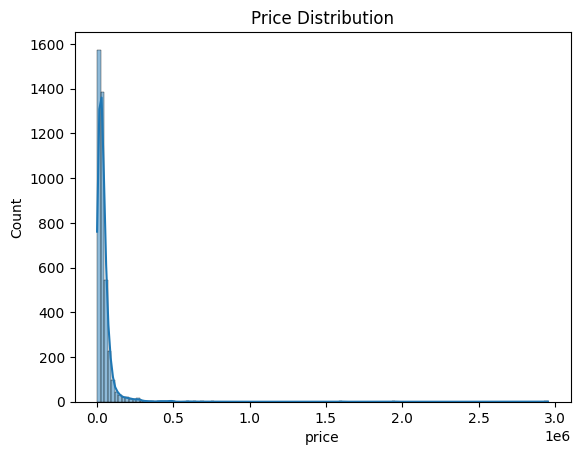

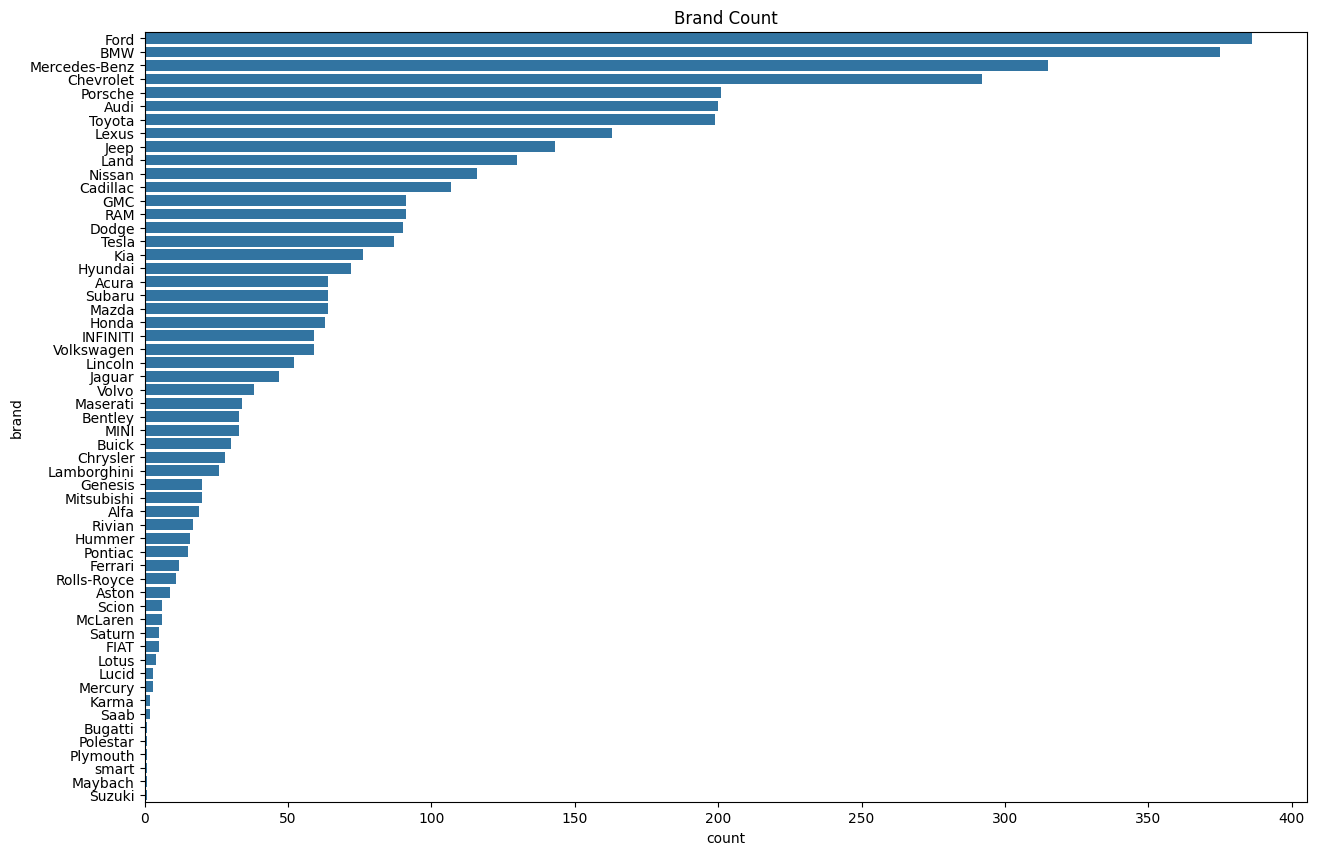

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of price
sns.histplot(df['price'].replace('[\$,]', '', regex=True).astype(float), kde=True)
plt.title("Price Distribution")
plt.show()

# Count plot for brands
plt.figure(figsize=(15,10))
sns.countplot(y=df['brand'], order=df['brand'].value_counts().index)
plt.title("Brand Count")
plt.show()


# 2.0 Data Preprocessing (Cleaning and Transformation)

## 2.1 Clean Price and Milage Column

In [14]:
# Remove $ and , then convert to float
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Remove 'mi.' and , then convert to float
df['milage'] = df['milage'].replace(r'[\,mi\.]', '', regex=True).astype(float)


In [15]:
df[['price', 'milage']].dtypes

price     float64
milage    float64
dtype: object

In [16]:
df[['price', 'milage']].head(10)

,price,milage
0,10300.0,51000.0
1,38005.0,34742.0
2,54598.0,22372.0
3,15500.0,88900.0
4,34999.0,9835.0
5,14798.0,136397.0
6,31000.0,84000.0
7,7300.0,242000.0
8,41927.0,23436.0
9,69950.0,34000.0


In [17]:
df['price'].astype(str).str.contains(r'[\$,]').sum()
df['milage'].astype(str).str.contains(r'[\,mi]').sum()

np.int64(0)

## 2.2 Handle the missing value

#### Handle missing value for fuel type

In [18]:
# Find the most common fuel type
df['fuel_type'].value_counts()


fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [19]:
# Fill missing values in 'fuel_type' with 'Gasoline'
df['fuel_type'].fillna('Gasoline', inplace=True)

# Replace "Unknown" and "–" with "Gasoline"
df['fuel_type'].replace(["Unknown", "–"], "Gasoline", inplace=True)


C:\Users\Jun Jie\AppData\Local\Temp\ipykernel_18912\3899616275.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['fuel_type'].fillna('Gasoline', inplace=True)
C:\Users\Jun Jie\AppData\Local\Temp\ipykernel_18912\3899616275.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

0       E85 Flex Fuel
1            Gasoline
2            Gasoline
3              Hybrid
4            Gasoline
            ...      
4004         Gasoline
4005         Gasoline
4006              NaN
4007         Gasoline
4008         Gasoline
Name: fuel_type, Length: 4009, dtype: str

In [20]:
df['fuel_type'].isnull().sum()


np.int64(170)

#### Handle missing value for Accident

In [21]:
# Find the most common accident type
df['accident'].value_counts()

accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64

In [22]:
# Fill missing values in 'accident' with 'No'
df['accident'].fillna('No', inplace=True)

C:\Users\Jun Jie\AppData\Local\Temp\ipykernel_18912\3650336841.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['accident'].fillna('No', inplace=True)


0       At least 1 accident or damage reported
1       At least 1 accident or damage reported
2                                None reported
3                                None reported
4                                None reported
                         ...                  
4004                             None reported
4005                             None reported
4006                             None reported
4007                             None reported
4008    At least 1 accident or damage reported
Name: accident, Length: 4009, dtype: str

#### Handle missing value for clean_title

In [23]:
# Find the most common clean_title type
df['clean_title'].value_counts()

clean_title
Yes    3413
Name: count, dtype: int64

In [24]:
# Fill missing values in 'clean_title' with 'Yes'
df['clean_title'].fillna('Yes', inplace=True)


C:\Users\Jun Jie\AppData\Local\Temp\ipykernel_18912\2382802223.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['clean_title'].fillna('Yes', inplace=True)


0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
4004    Yes
4005    Yes
4006    Yes
4007    Yes
4008    Yes
Name: clean_title, Length: 4009, dtype: str

#### Double check the missing value

In [25]:
df.isnull().sum()


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

## 2.3 Simplify rare categories for Trasmission column

In [26]:
# Step 1: See top 5 most common transmissions
df['transmission'].value_counts().head(20)


transmission
A/T                               1037
8-Speed A/T                        406
Transmission w/Dual Shift Mode     398
6-Speed A/T                        362
6-Speed M/T                        248
Automatic                          237
7-Speed A/T                        209
8-Speed Automatic                  176
10-Speed A/T                       119
5-Speed A/T                         86
9-Speed A/T                         74
6-Speed Automatic                   73
4-Speed A/T                         72
1-Speed A/T                         64
CVT Transmission                    62
5-Speed M/T                         59
10-Speed Automatic                  56
9-Speed Automatic                   47
M/T                                 40
Automatic CVT                       37
Name: count, dtype: int64

In [27]:
# Step 2: Keep only top 5, group the rest as "Other"
top_transmissions = df['transmission'].value_counts().nlargest(5).index
df['transmission'] = df['transmission'].apply(lambda x: x if x in top_transmissions else 'Other')


In [28]:
# Step 3: Double-check the updated categories
df['transmission'].value_counts()

transmission
Other                             1558
A/T                               1037
8-Speed A/T                        406
Transmission w/Dual Shift Mode     398
6-Speed A/T                        362
6-Speed M/T                        248
Name: count, dtype: int64

## 2.4 Encode Categorical Features

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode brand
df['brand'] = le.fit_transform(df['brand'])

# Encode fuel type
df['fuel_type'] = le.fit_transform(df['fuel_type'])

# Encode transmission
df['transmission'] = le.fit_transform(df['transmission'])

# Manually map clean_title
df['clean_title'] = df['clean_title'].map({'Yes': 1, 'No': 0})

# Manually map accident values
df['accident'] = df['accident'].map({'None reported': 0,'At least 1 accident or damage reported': 1})

# Drop any rows that still have NaN after encoding
df = df.dropna()

print("Remaining rows after dropping NaN:", df.shape[0])

Remaining rows after dropping NaN: 3413


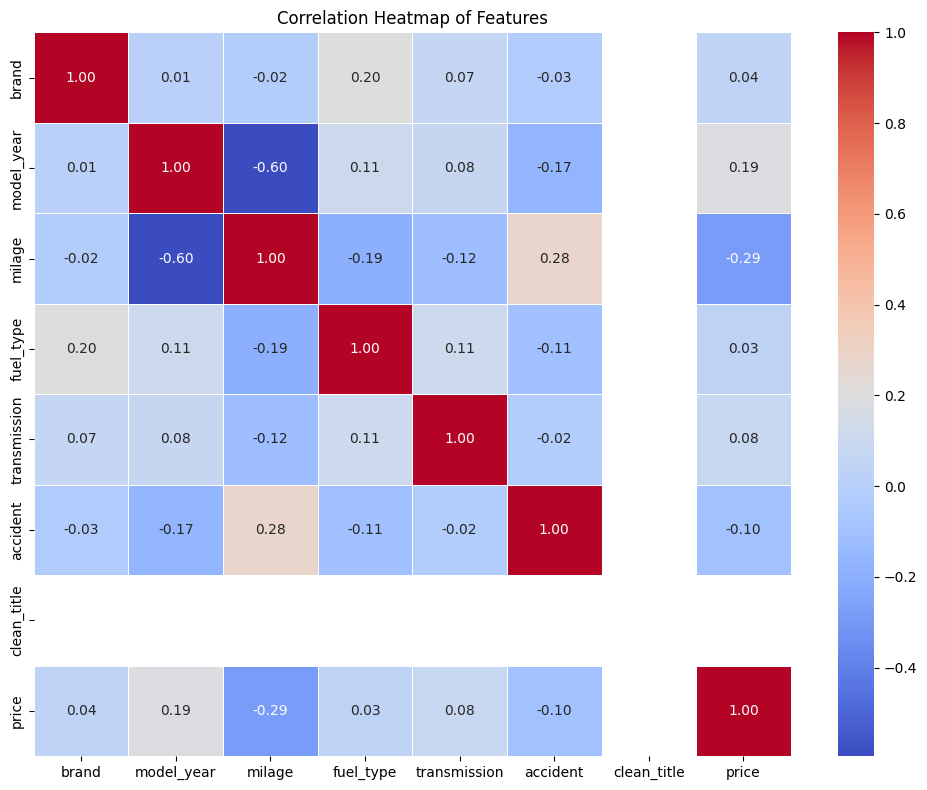

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

In [31]:
df = df.drop(['model', 'engine', 'ext_col', 'int_col', 'accident'], axis=1)


#### Convert price into Price_Class (Classification)

In [32]:
# Define the bin edges for price groups
bins = [0, 15000, 30000, df['price'].max()]  # max() gets the highest price in dataset

# Define the class labels for each price range
labels = ['Low', 'Medium', 'High']

# Use pd.cut to categorize each row's price into a class
df['price_class'] = pd.cut(df['price'], bins=bins, labels=labels)

In [33]:
# Check the distribution (counts) of each class
print(df['price_class'].value_counts())

price_class
High      1596
Medium    1009
Low        808
Name: count, dtype: int64


#### Define X and Y

In [34]:
# Define input features (X) and classification target (y)

X = df[['brand', 'model_year', 'milage', 'fuel_type', 'transmission', 'clean_title']]

y = df['price_class']  # Categorical: Low / Medium / High

#### Splitting Data

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (2730, 6)
Test set size: (683, 6)


#### Normalization

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill any remaining NaN with column median
imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)


In [38]:
from sklearn.preprocessing import LabelEncoder

# Encode y_train and y_test
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# 4.0 Modelling

#### 4.1 Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_encoded)

# 2. Make predictions on the test set
y_pred_log = log_model.predict(X_test_scaled)

# 3. Evaluate performance
accuracy  = accuracy_score(y_test_encoded, y_pred_log)
precision = precision_score(y_test_encoded, y_pred_log, average='weighted', zero_division=0)
recall    = recall_score(y_test_encoded, y_pred_log, average='weighted')
f1        = f1_score(y_test_encoded, y_pred_log, average='weighted')

# 4. Print results
print("Logistic Regression Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Logistic Regression Performance:
Accuracy  : 0.6764
Precision : 0.6612
Recall    : 0.6764
F1 Score  : 0.6650


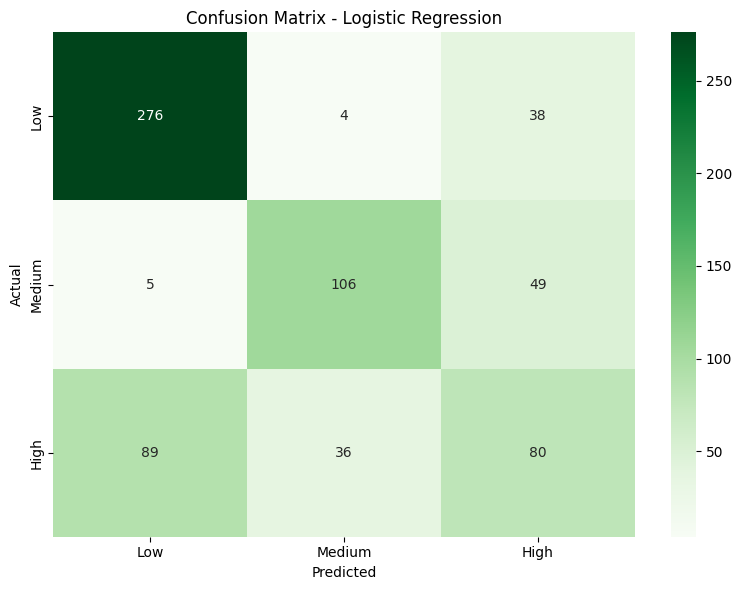

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_log = confusion_matrix(y_test_encoded, y_pred_log, labels=[0, 1, 2])

# Plot it using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

#### 4.2 K-Nearest Neighbors (KNN)

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Train the KNN model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# 2. Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)

# 3. Evaluate performance
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

# 4. Print the results
print("KNN Classifier Performance:")
print(f"Accuracy  : {accuracy_knn:.4f}")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1 Score  : {f1_knn:.4f}")


KNN Classifier Performance:
Accuracy  : 0.6896
Precision : 0.6760
Recall    : 0.6896
F1 Score  : 0.6794


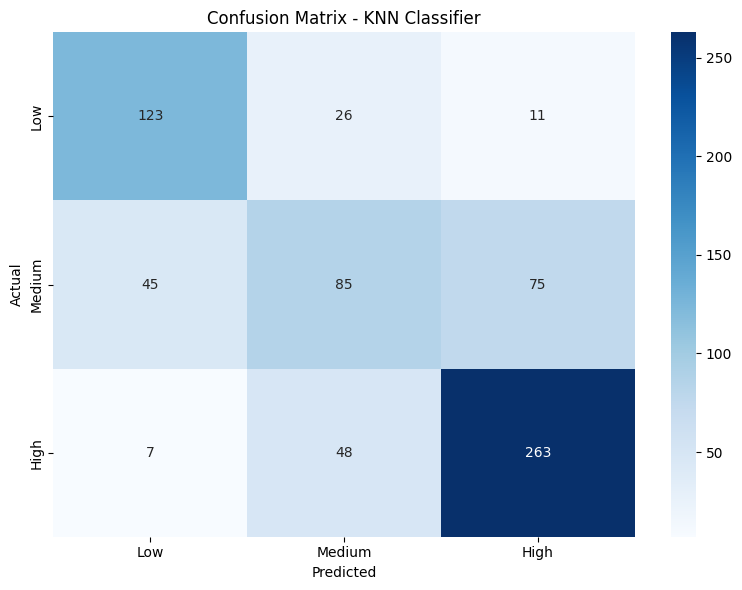

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train KNN again (just in case)
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# Predict using KNN
y_pred_knn = knn_model.predict(X_test_scaled)

# Generate confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=['Low', 'Medium', 'High'])

# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN Classifier')
plt.tight_layout()
plt.show()

#### 4.3 SVM Classifier

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Train the SVM model
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# 2. Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

# 3. Evaluate performance
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

# 4. Print the results
print("SVM Classifier Performance:")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1 Score  : {f1_svm:.4f}")


SVM Classifier Performance:
Accuracy  : 0.6984
Precision : 0.6804
Recall    : 0.6984
F1 Score  : 0.6829


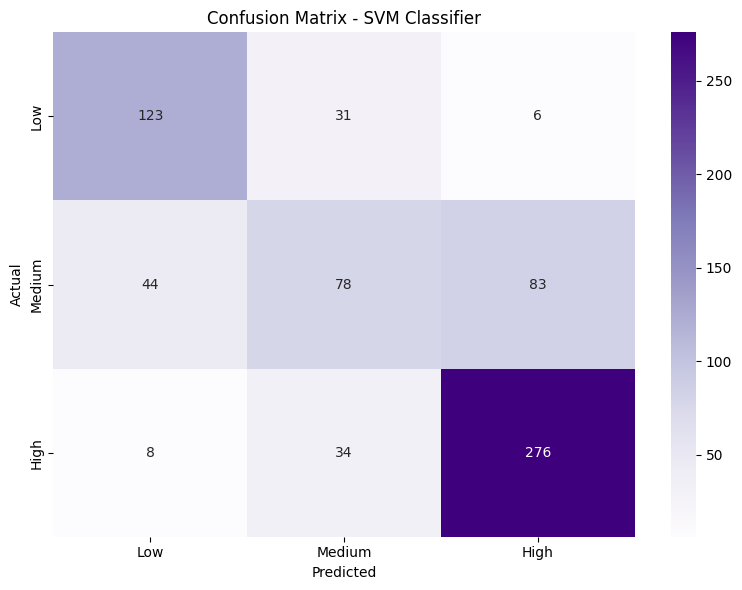

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train SVM model
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# Predict using SVM
y_pred_svm = svm_model.predict(X_test_scaled)

# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['Low', 'Medium', 'High'])

# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Classifier')
plt.tight_layout()
plt.show()

#### 4.4 Gradient Boosting (XGBoost)

In [50]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
# Import libraries
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train the XGBoost model with encoded y
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train_encoded)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate using encoded y
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test_encoded, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_encoded, y_pred_xgb, average='weighted')

print("XGBoost Classifier Performance:")
print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")


XGBoost Classifier Performance:
Accuracy  : 0.7130
Precision : 0.7057
Recall    : 0.7130
F1 Score  : 0.7087


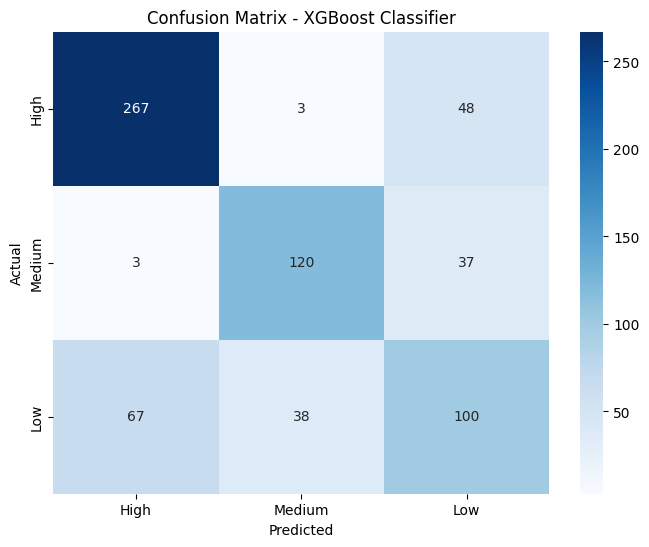

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Medium', 'Low'],
            yticklabels=['High', 'Medium', 'Low'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix - XGBoost Classifier")
plt.show()

# 5.0 Comparison

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Pull results directly from all 4 trained models
model_comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'KNN', 'SVM', 'XGBoost'],
    'Accuracy':  [accuracy,     accuracy_knn,  accuracy_svm,  accuracy_xgb],
    'Precision': [precision,    precision_knn, precision_svm, precision_xgb],
    'Recall':    [recall,       recall_knn,    recall_svm,    recall_xgb],
    'F1 Score':  [f1,           f1_knn,        f1_svm,        f1_xgb]
})

model_comparison = model_comparison.set_index('Model')
print("=== Model Performance Comparison ===")
display(model_comparison.style
    .format("{:.4f}")
    .apply(lambda s: ['background-color: green' if v == s.max() else '' for v in s])
)

=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.6764,0.6612,0.6764,0.6650
KNN,0.6896,0.6760,0.6896,0.6794
SVM,0.6984,0.6804,0.6984,0.6829
XGBoost,0.7130,0.7057,0.7130,0.7087


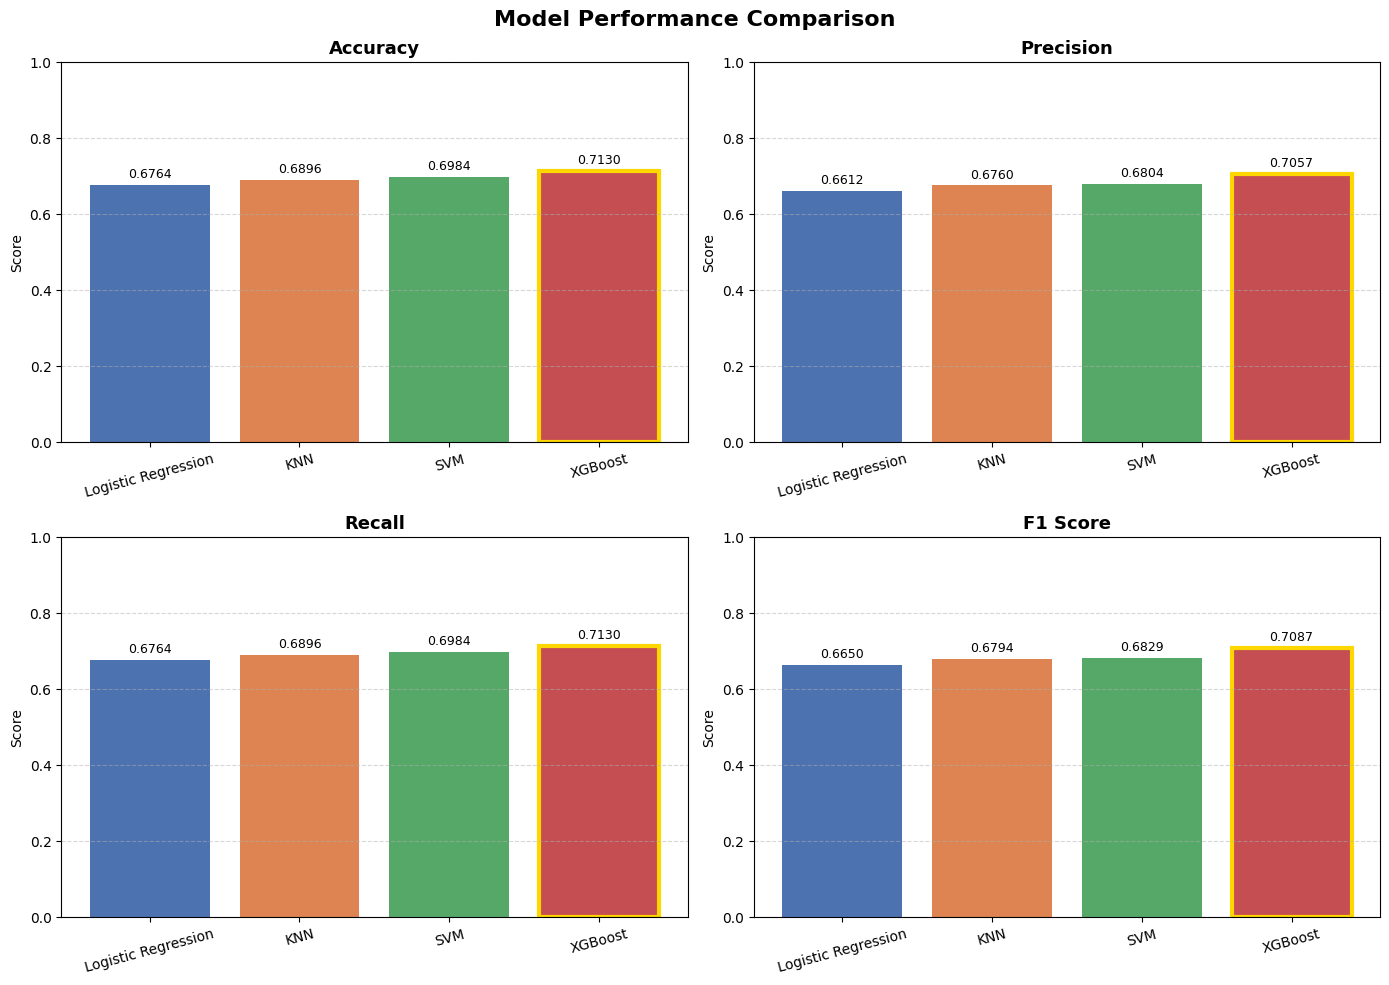

In [67]:
# ✅ Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.bar(model_comparison.index, model_comparison[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotate each bar with its value
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9)

    # Highlight the best bar with a border
    best_idx = model_comparison[metric].idxmax()
    best_bar = bars[model_comparison.index.get_loc(best_idx)]
    best_bar.set_edgecolor('gold')
    best_bar.set_linewidth(3)

plt.tight_layout()
plt.show()

# 6.0 Model Deployment

In [58]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import streamlit as st
import pickle
import numpy as np

In [69]:
# Save the best model (e.g. KNN)
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

# Save the scaler too!
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [70]:
# Load the saved model and scaler
with open("xgb_model.pkl", "rb") as file:
    model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

In [71]:
# === Mapping Dictionaries ===
brand_map = {
    'Ford': 0,
    'Hyundai': 1,
    'Lexus': 2,
    'INFINITI': 3,
    'Audi': 4,
    'Acura': 5,
    'BMW': 6,
    'Tesla': 7,
    'Land': 8,
    'Aston': 9,
    'Toyota': 10,
    'Lincoln': 11,
    'Jaguar': 12,
    'Mercedes-Benz': 13,
    'Dodge': 14,
    'Nissan': 15,
    'Genesis': 16,
    'Chevrolet': 17,
    'Kia': 18,
    'Jeep': 19,
    'Bentley': 20,
    'Honda': 21,
    'Lucid': 22,
    'MINI': 23,
    'Porsche': 24,
    'Hummer': 25,
    'Chrysler': 26,
    'Volvo': 27,
    'Cadillac': 28,
    'Lamborghini': 29,
    'Maserati': 30,
    'Volkswagen': 31,
    'Subaru': 32,
    'Rivian': 33,
    'GMC': 34,
    'RAM': 35,
    'Alfa': 36,
    'Ferrari': 37,
    'Scion': 38,
    'Mitsubishi': 39,
    'Mazda': 40,
    'Saturn': 41,
    'Bugatti': 42,
    'Polestar': 43,
    'Rolls-Royce': 44,
    'McLaren': 45,
    'Buick': 46,
    'Lotus': 47,
    'Pontiac': 48,
    'FIAT': 49,
    'Karma': 50,
    'Saab': 51,
    'Mercury': 52,
    'Plymouth': 53,
    'smart': 54,
    'Maybach': 55,
    'Suzuki': 56
}


fuel_map = {
    'Gasoline': 0,
    'Hybrid': 1,
    'E85 Flex Fuel': 2,
    'Diesel': 3,
    'Plug-In Hybrid': 4,
    'Other': 5
}

transmission_map = {
    'A/T': 0,
    '8-Speed A/T': 1,
    'Dual Shift Mode': 2,
    '6-Speed A/T': 3,
    '6-Speed M/T': 4,
    'Other': 5
}


In [72]:
st.title("Used Car Price Category Predictor")
st.subheader("Enter car details below:")

# === User Inputs via Dropdowns and Sliders ===
brand = st.selectbox("Brand", list(brand_map.keys()))
model_year = st.number_input("Model Year", min_value=1970, max_value=2024, value=2020)
milage = st.number_input("Mileage (in miles)", min_value=0, step=1000)
fuel_type = st.selectbox("Fuel Type", list(fuel_map.keys()))
transmission = st.selectbox("Transmission", list(transmission_map.keys()))
clean_title = st.radio("Clean Title?", ['Yes', 'No'])


2026-04-21 23:48:25.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.795 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.797 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:25.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [73]:
# === On Button Click, Predict the Class ===
if st.button("Predict Price Class"):
    # Convert to encoded values
    brand_encoded = brand_map[brand]
    fuel_encoded = fuel_map[fuel_type]
    trans_encoded = transmission_map[transmission]
    title_encoded = 1 if clean_title == 'Yes' else 0

    # Combine input
    user_input = np.array([[brand_encoded, model_year, milage, fuel_encoded, trans_encoded, title_encoded]])

    # Scale and Predict
    user_scaled = scaler.transform(user_input)
    prediction = model.predict(user_scaled)[0]

    # Mapping prediction number to text label
    prediction_label = {0: 'High', 1: 'Medium', 2: 'Low'}[prediction]

    st.success(f"Predicted Price Category: **{prediction_label}**")


2026-04-21 23:48:26.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:26.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:26.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:26.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:26.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-21 23:48:26.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [74]:
code = """
import streamlit as st
import pickle
import numpy as np

# === Load Model and Scaler ===
with open("xgb_model.pkl", "rb") as file:
    model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# === Mappings ===
brand_map = {
    'Ford': 0, 'Hyundai': 1, 'Lexus': 2, 'INFINITI': 3, 'Audi': 4, 'Acura': 5, 'BMW': 6, 'Tesla': 7, 
    'Land': 8, 'Aston': 9, 'Toyota': 10, 'Lincoln': 11, 'Jaguar': 12, 'Mercedes-Benz': 13, 'Dodge': 14, 'Nissan': 15, 
    'Genesis': 16, 'Chevrolet': 17, 'Kia': 18, 'Jeep': 19, 'Bentley': 20, 'Honda': 21, 'Lucid': 22, 'MINI': 23, 'Porsche': 24, 
    'Hummer': 25, 'Chrysler': 26, 'Volvo': 27, 'Cadillac': 28, 'Lamborghini': 29, 'Maserati': 30, 'Volkswagen': 31, 'Subaru': 32, 
    'Rivian': 33, 'GMC': 34, 'RAM': 35, 'Alfa': 36, 'Ferrari': 37, 'Scion': 38, 'Mitsubishi': 39, 'Mazda': 40, 'Saturn': 41, 
    'Bugatti': 42, 'Polestar': 43, 'Rolls-Royce': 44, 'McLaren': 45, 'Buick': 46, 'Lotus': 47, 'Pontiac': 48, 'FIAT': 49, 
    'Karma': 50, 'Saab': 51, 'Mercury': 52, 'Plymouth': 53, 'smart': 54, 'Maybach': 55, 'Suzuki': 56
}

fuel_map = {
    'Gasoline': 0,
    'Hybrid': 1,
    'E85 Flex Fuel': 2,
    'Diesel': 3,
    'Plug-In Hybrid': 4,
    'Other': 5
}

transmission_map = {
    'A/T': 0,
    '8-Speed A/T': 1,
    'Dual Shift Mode': 2,
    '6-Speed A/T': 3,
    '6-Speed M/T': 4,
    'Other': 5
}

# === UI ===
st.title("Used Car Price Category Predictor")
st.subheader("Enter car details below:")

brand = st.selectbox("Brand", list(brand_map.keys()))
model_year = st.number_input("Model Year", min_value=1970, max_value=2024, value=2020)
milage = st.number_input("Mileage (in miles)", min_value=0, step=1000)
fuel_type = st.selectbox("Fuel Type", list(fuel_map.keys()))
transmission = st.selectbox("Transmission", list(transmission_map.keys()))
clean_title = st.radio("Clean Title?", ['Yes', 'No'])

# === Predict ===
if st.button("Predict Price Class"):
    user_input = [[
        brand_map[brand], model_year, milage,
        fuel_map[fuel_type], transmission_map[transmission],
        1 if clean_title == 'Yes' else 0
    ]]
    user_scaled = scaler.transform(user_input)
    prediction = model.predict(user_scaled)[0]

    # Mapping prediction number to text label
    prediction_label = {0: 'High', 1: 'Medium', 2: 'Low'}[prediction]

    st.success(f"Predicted Price Category: **{prediction_label}**")
"""

# Save to app.py with UTF-8 encoding to support emojis
with open("app.py", "w", encoding="utf-8") as f:
    f.write(code)


In [75]:
!streamlit run app.py

^C
